### Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud


### Read the Data

In [ ]:
df = pd.read_csv("/content/sample_data/tweet.csv")

In [ ]:
df.head()

,Unnamed: 0,sentimen,tweet
0,0,negatif,Kata @prabowo Indonesia tidak dihargai bangsa ...
1,1,netral,"Batuan Langka, Tasbih Jokowi Hadiah dari Habib..."
2,2,netral,"Di era Jokowi, ekonomi Indonesia semakin baik...."
3,3,positif,"Bagi Sumatera Selatan, Asian Games berdampak p..."
4,4,negatif,Negara kita ngutang buat bngun infrastruktur y...


Data sentiment tweet berhasil dibaca

## EDA

### Quality checks

In [ ]:
df.columns

Index(['Unnamed: 0', 'sentimen', 'tweet'], dtype='object')

In [ ]:
df = df.drop(columns=["Unnamed: 0"])

Kolom ini tidak akan terpakai, jadi didrop saja

In [ ]:
df.columns

Index(['sentimen', 'tweet'], dtype='object')

In [ ]:
print(df.shape)

(1815, 2)


Terdapat 1815 data tweet dan 2 kolom

In [ ]:
print(df.dtypes)


sentimen    object
tweet       object
dtype: object


Terdapat label dan tweetnya dan juga tipe datanya sesuai(untuk EDA), nantinya untuk sentimen perlu diencode(label encoding), tapi overall sudah sesuai dengan tujuan kita untuk klasifikasi sentiment

In [ ]:
print("\nMissing values:\n", df.isna().sum())
print("Duplicate tweets:", df.duplicated(subset=["tweet"]).sum())
print("Labels:", df["sentimen"].unique())


Missing values:
 sentimen    0
tweet       0
dtype: int64
Duplicate tweets: 0
Labels: ['negatif' 'netral' 'positif']


Data tidak ada yang missing ataupun duplikat, ini bagus sehingga ga perlu ditreat gimana gimana, sedangkan untuk labelnya ada 3 yang positif, yang netral, dan yang negatif

### Label distribution


Label counts:
           count
sentimen       
positif     612
netral      607
negatif     596


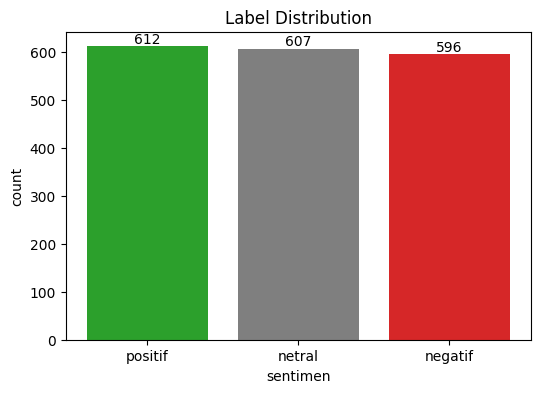

In [ ]:
label_counts = df["sentimen"].value_counts()
print("\nLabel counts:\n", label_counts.to_frame(name="count"))

labels = label_counts.index.tolist()
counts = label_counts.values.tolist()

color_map = {
    "positif": "tab:green",
    "netral": "tab:gray",
    "negatif": "tab:red",
}
colors = [color_map.get(lbl, "tab:blue") for lbl in labels]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=colors)
plt.title("Label Distribution")
plt.xlabel("sentimen")
plt.ylabel("count")

for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha="center", va="bottom")

Dataset sudah cukup seimbang, sehingga akurasi untuk evaluasi nanti akan cukup masuk akal, tapi tetap pakai macro F1 / per-class precision-recall supaya tetap fair antar kelas

### Length


Length stats (overall):
           char_len     word_len
count  1815.000000  1815.000000
mean    194.669972    24.934435
std      75.533506    10.820302
min      27.000000     5.000000
25%     134.000000    15.000000
50%     200.000000    24.000000
75%     258.000000    34.000000
max     668.000000    53.000000

Length stats (by label):
             char_len                   word_len               
                mean median min  max       mean median min max
sentimen                                                      
negatif   189.278523  193.0  30  408  26.810403   26.5   5  52
netral    187.227348  189.0  39  668  20.387150   18.0   5  53
positif   207.302288  221.5  27  390  27.617647   28.0   5  52


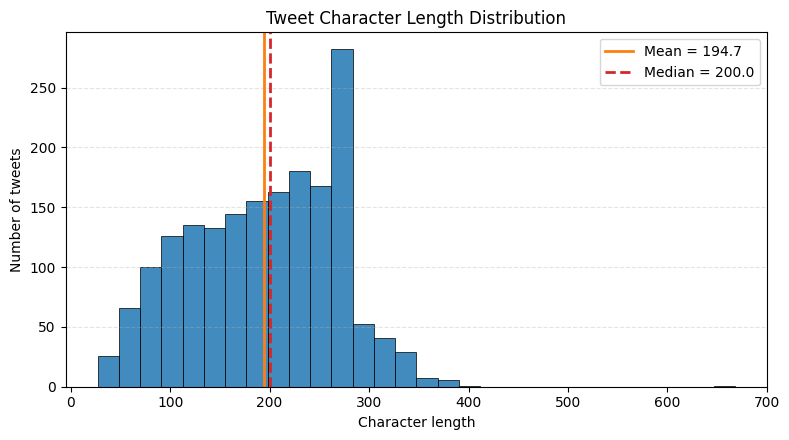

In [ ]:
df["char_len"] = df["tweet"].astype(str).str.len()
df["word_len"] = df["tweet"].astype(str).str.split().str.len()

print("\nLength stats (overall):\n", df[["char_len", "word_len"]].describe())
print("\nLength stats (by label):\n",
      df.groupby("sentimen")[["char_len", "word_len"]].agg(["mean", "median", "min", "max"]))

x = df["char_len"].dropna().values
mean_x = x.mean()
median_x = np.median(x)

plt.figure(figsize=(8, 4.5))
plt.hist(
    x,
    bins=30,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85
)

plt.axvline(mean_x, color="tab:orange", linewidth=2, label=f"Mean = {mean_x:.1f}")
plt.axvline(median_x, color="tab:red", linestyle="--", linewidth=2, label=f"Median = {median_x:.1f}")

plt.title("Tweet Character Length Distribution")
plt.xlabel("Character length")
plt.ylabel("Number of tweets")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

Dataset menunjukkan variasi panjang tweet yang cukup lebar. Secara keseluruhan, `char_len` memiliki rata rataa 194.7 dan median 200, dengan rentang 27-668 karakter, sedangkan `word_len` memiliki mean 24.93 dan median 24, dengan rentang 5-53 kata. Nilai mean dan median yang berdekatan menunjukkan bahwa mayoritas tweet berada pada panjang moderat, tetapi keberadaan ekor kanan pada histogram dan nilai maksimum yang jauh lebih tinggi menandakan adanya sejumlah outlier tweet yang sangat panjang.

Jika dilihat per label, kelas positif cenderung lebih panjang dibandingkan negatif dan netral. Namun, outlier paling ekstrem justru muncul pada kelas netral, dengan `char_len` maksimum 668. Temuan ini menunjukkan bahwa tweet yang sangat panjang memang ada, tetapi jumlahnya sedikit dan tidak merepresentasikan mayoritas data.

Berdasarkan distribusi tersebut, penentuan `max_len` untuk model tidak menggunakan nilai maksimum, karena akan menyebabkan padding berlebihan pada sebagian besar data. Mean dan median berguna untuk menunjukkan pusat distribusi, tetapi kurang ideal sebagai batas input karena median terlalu pendek dan mean tidak menjamin cakupan mayoritas data. Oleh karena itu, digunakan **persentil ke-95 (p95)** agar sekitar 95% sequence tetap terwakili secara utuh, sementara pengaruh outlier dapat dibatasi.




### Simple preprocessing for Top 20 Unigram dan Bigram

In [ ]:
import re

In [ ]:
def clean_for_eda(text: str) -> str:
    text = str(text).lower()

    # hilangkan urls & mentions
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)

    # simpan hashtag word tapi hilangkan '#'
    text = re.sub(r"#(\w+)", r"\1", text)

    # alfanumerik only
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["tweet_clean"] = df["tweet"].apply(clean_for_eda)

Untuk melihat top word disini kami hilangkan dulu url, mention user, buang # tapi wordnya tetap ambil, dan haps nonaplhanumarik seperti tanda baca atau simbol dan tapikan spasi(ini sementara sebelum text preprocessing khusus untuk model)

### Top 20 unigram & bigram

In [ ]:
def top_ngrams(corpus, ngram_range=(1, 1), top_n=20, min_df=2):
    vec = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    X = vec.fit_transform(corpus)

    terms = np.array(vec.get_feature_names_out())
    freqs = np.asarray(X.sum(axis=0)).ravel()

    top_idx = np.argsort(freqs)[::-1][:top_n]
    return pd.DataFrame({"term": terms[top_idx], "freq": freqs[top_idx]})

top_uni = top_ngrams(df["tweet_clean"], ngram_range=(1, 1), top_n=20, min_df=2)
top_bi  = top_ngrams(df["tweet_clean"], ngram_range=(2, 2), top_n=20, min_df=2)

print("Top 20 Unigram (Overall):")
print(top_uni.to_string(index=False))

print("\nTop 20 Bigram (Overall):")
print(top_bi.to_string(index=False))

Top 20 Unigram (Overall):
     term  freq
  ekonomi   927
      dan   749
  prabowo   708
   jokowi   680
       yg   666
       di   530
      pak   480
     gaji   447
    sandi   388
      itu   386
 presiden   382
      ini   335
     yang   326
indonesia   314
     akan   298
    harga   293
    tidak   273
     bisa   231
   rakyat   210
    untuk   198

Top 20 Bigram (Overall):
                             term  freq
                    prabowo sandi   274
                      pic twitter   167
                      twitter com   167
                       ambil gaji   126
                       pak jokowi   121
                ekonomi indonesia   110
                      pak prabowo    93
              pertumbuhan ekonomi    78
                    ekonomi makro    77
pilihjelasislamnya pilihbajuputih    58
pilihorangbaik pilihjelasislamnya    58
                       tidak akan    56
                    jika terpilih    55
                 presiden sebelum    54
            

Insight:
- Topik dataset sangat dominan politik–ekonomi Indonesia.
- Kata fungsi/stopword umum masih mendominasi (dan, di, itu, ini, yang/yg, untuk, akan, bisa).
- Ada noise khas Twitter/link yang masih lolos cleaning:
bigram “pic twitter” dan “twitter com” tinggi (167) -> berasal dari pic.twitter.com/...
- Ada frasa kampanye/hashtag spesifik yang kemungkinan besar bukan sinyal sentimen murni:
pilihjelasislamnya pilihbajuputih, pilihorangbaik pilihjelasislamnya , uni mungkin berguna untuk model terutama konteks pemilu sehingga kita mungkin hapus # tapi tetap ambil jargonnya

Implikasi ke preprocessing:
- Kita bisa melakukan cleaning dasar seperti lowercase tadi yaitu hapus URL (http..., www...) dan mention (@user), ubah hashtag: simpan kata tapi hilangkan #, dan hapus tanda baca/simbol, rapikan spasi, lalu juga tambahkan cleaning khusus link Twitter (penting karena bigram “pic twitter”, “twitter com” muncul): hapus pic.twitter.com dan sisa token pic, twitter, com
- Tambahkan “domain stopword list” minimal untuk noise platform dengan membuang pic, twitter, com, rt, amp
- Normalisasi ringan slang yang paling sering: yg -> yang, gk/ga -> tidak




### Wordcloud

In [ ]:
from wordcloud import WordCloud

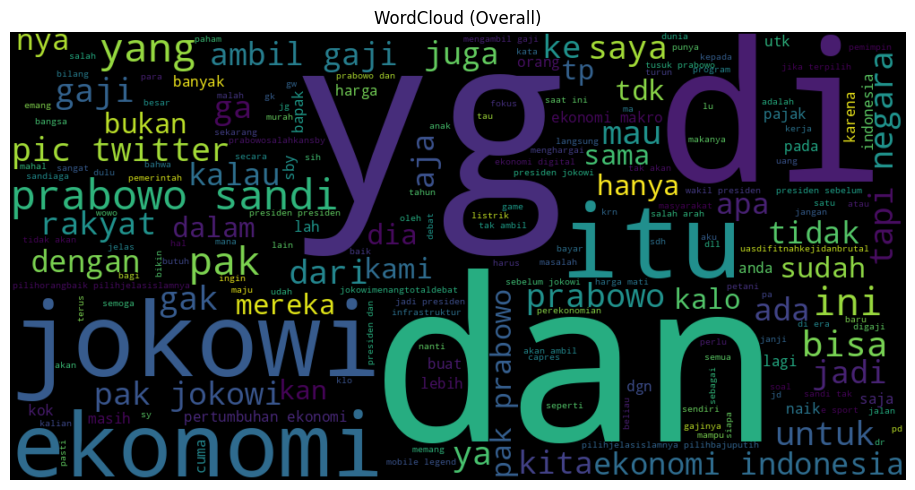

In [ ]:
# overall wordcloud
all_text = " ".join(df["tweet_clean"].dropna().tolist())
wc = WordCloud(width=1000, height=500).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud (Overall)")
plt.tight_layout()
plt.show()

Ini sesuai dengan temuan kita sebelumnya seperti "yg" yang sering muncuk, noise dari twitter seperti "pic twitter", slang negasi yang sering muncul, jadi kita akan:
- Cleaning dasar: lowercase, hapus URL & mention, hilangkan # tapi simpan kata hashtag, hapus simbol & rapikan spasi.
- Cleaning khusus Twitter: hapus pic.twitter.com/twitter.com dan buang token pic/twitter/com.
- Tambah domain stopword platform: pic, twitter, com, rt, amp.
- Normalisasi slang ringan: yg->yang, dgn->dengan, tdk->tidak

## Text preprocessing

In [ ]:
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
import tensorflow as tf

### Stopword(NLTK) + dari EDA

In [ ]:
nltk.download("stopwords", quiet=True)

stop_id = set(stopwords.words("indonesian"))

# Keepp Negasi untuk sentimen
negation_keep = {"tidak", "tak", "bukan", "jangan", "belum", "tanpa"}
stop_id = stop_id - negation_keep

# Tambahan stopword/noise dari EDA (platform tokens)
domain_stop = {"pic", "twitter", "com", "rt", "amp", "tco"}
stop_id = stop_id.union(domain_stop)

Disini kami mencoba melakukan pengurangan jumlah fitur untuk membantu menekan noise dan potensi overfitting. Caranya adalah dengan menggunakan daftar `stopword` bahasa Indonesia dari NLTK, kemudian menyesuaikannya agar tetap sesuai untuk tugas analisis sentimen. Secara default, beberapa kata negasi seperti `tidak`, `tak`, `bukan`, `jangan`, `belum`, dan `tanpa` sebenarnya termasuk kata yang sering dihapus dalam preprocessing umum, padahal kata-kata tersebut justru penting karena dapat membalikkan makna sentimen. Oleh karena itu, kata-kata negasi tersebut sengaja dipertahankan.

Selain stopword umum, ditambahkan juga **domain stopword** berdasarkan hasil EDA, yaitu token-token yang sering muncul tetapi tidak memberikan informasi sentimen yang bermakna, seperti `pic`, `twitter`, `com`, `rt`, `amp`, dan `tco`. Token seperti `pic` biasanya berasal dari penanda gambar, `rt` dari retweet, sedangkan `twitter`, `com`, dan `tco` sering muncul dari tautan atau format khas platform. Dengan menghapus token-token tersebut, representasi teks menjadi lebih fokus pada kata-kata yang benar-benar relevan terhadap opini pengguna.

### Normalization Mapping

In [ ]:
NORMALIZE_MAP = {
    # umum
    "yg": "yang",
    "dgn": "dengan",
    "dg": "dengan",
    "utk": "untuk",
    "krn": "karena",
    "dr": "dari",
    "pd": "pada",
    "sdh": "sudah",
    "udh": "sudah",
    "dah": "sudah",
    "klo": "kalau",
    "kalo": "kalau",

    # negasi
    "ga": "tidak",
    "gak": "tidak",
    "gk": "tidak",
    "nggak": "tidak",
    "enggak": "tidak",
    "tdk": "tidak",
    "tak": "tidak",
    "bkn": "bukan",
    "jgn": "jangan",
}

Disni kami melakukan normalisasi kata kata yang umum typo, seperti `yg` yang ditemukan di EDA, lalu kata negasi dinormalisasi agar terhitung 1 token

### Preprocessing function

In [ ]:
URL_PAT = re.compile(r"(https?://\S+|www\.\S+|pic\.twitter\.com/\S+|twitter\.com/\S+|t\.co/\S+)")
MENTION_PAT = re.compile(r"@\w+")
HASHTAG_PAT = re.compile(r"#(\w+)")
NON_ALNUM_PAT = re.compile(r"[^a-z0-9\s]")
MULTISPACE_PAT = re.compile(r"\s+")
ELONG_PAT = re.compile(r"([a-z])\1{2,}")  # contoh: baguuuus -> baguus

def preprocess_text(text: str, stop_set: set, max_token_len: int = 30, min_token_len: int = 2) -> str:
    text = str(text).lower()

    # hapus url & mention
    text = re.sub(URL_PAT, " ", text)
    text = re.sub(MENTION_PAT, " ", text)

    # simpan kata hashtag, buang '#'
    text = re.sub(HASHTAG_PAT, r"\1", text)

    # buang simbol, rapikan spasi
    text = re.sub(NON_ALNUM_PAT, " ", text)
    text = re.sub(MULTISPACE_PAT, " ", text).strip()

    if not text:
        return ""

    tokens = []
    for tok in text.split():
        # normalisasi slang/negasi
        tok = NORMALIZE_MAP.get(tok, tok)

        # kurangi huruf kepanjangan (baguuuus -> baguus)
        tok = re.sub(ELONG_PAT, r"\1\1", tok)

        # buang token noise/panjang berlebihan
        if len(tok) > max_token_len:
            continue
        if len(tok) < min_token_len:
            continue

        # stopword filtering (negasi sudah diproteksi dari stop_set)
        if tok in stop_set:
            continue

        tokens.append(tok)

    return " ".join(tokens)

df["tweet_clean"] = df["tweet"].apply(lambda x: preprocess_text(x, stop_id))

Next, kita buat fungsi yag digunakan untuk membersihkan dan menormalkan teks sebelum masuk ke tahap pemodelan. Prosesnya dimulai dengan mengubah semua huruf menjadi lowercase, lalu menghapus URL dan mention karena umumnya tidak membawa informasi sentimen yang relevan. Hashtag tidak dihapus sepenuhnya; simbol `#` dibuang tetapi kata setelahnya tetap dipertahankan agar informasi topik masih bisa digunakan.

Setelah itu, karakter non-alfanumerik dihapus dan spasi dirapikan. Pada level token, dilakukan normalisasi kata menggunakan `NORMALIZE_MAP`, pengurangan huruf berulang berlebihan, pembuangan token yang terlalu pendek atau terlalu panjang, serta filtering stopword. Dengan langkah ini, teks akhir menjadi lebih bersih, lebih konsisten, dan lebih fokus pada kata-kata yang informatif untuk analisis sentimen.

In [ ]:
df.head(30)

,sentimen,tweet,char_len,word_len,tweet_clean
0,negatif,Kata @prabowo Indonesia tidak dihargai bangsa ...,195,19,indonesia tidak dihargai bangsa asing berita h...
1,netral,"Batuan Langka, Tasbih Jokowi Hadiah dari Habib...",93,11,batuan langka tasbih jokowi hadiah habib luthf...
2,netral,"Di era Jokowi, ekonomi Indonesia semakin baik....",126,11,era jokowi ekonomi indonesia 01indonesiamaju j...
3,positif,"Bagi Sumatera Selatan, Asian Games berdampak p...",128,17,sumatera selatan asian games berdampak ekonomi...
4,negatif,Negara kita ngutang buat bngun infrastruktur y...,244,34,negara ngutang bngun infrastruktur udah dipake...
5,netral,"Yg bisikin pak jokowi, cm mikirin perputaran d...",276,39,bisikin jokowi cm mikirin perputaran duit golo...
6,positif,Masa tenang msih ngoceh aja..ttp jokowi harga ...,53,8,tenang msih ngoceh aja ttp jokowi harga mati
7,positif,#UASdifitnahKejiBalasDiTPS kerjasa ekonomi b...,146,14,uasdifitnahkejibalasditps kerjasa ekonomi bila...
8,netral,"Iya bener Aa, kita MANTAP kan pilihan ke Pemim...",285,45,iya bener aa mantap pilihan pemimpin bs solusi...
9,negatif,Prabowo-Sandi Sepakat Tak Ambil Gaji karena Ne...,238,14,prabowo sandi sepakat tidak ambil gaji negara ...


Hasilnya sudah terlihay jelas dimana sudah lowercase semua, @ dihilangkan, # hilang tapi tetap dikeep, dan jika ada emoji(selain alfanumerik) dihapus

In [ ]:
### Split Train/Val/Test (stratify)

In [ ]:
X = df["tweet_clean"]
y = df["sentimen"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Sizes:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

print("\nLabel distribution (train):")
print(y_train.value_counts(normalize=True).round(4))

print("\nLabel distribution (val):")
print(y_val.value_counts(normalize=True).round(4))

print("\nLabel distribution (test):")
print(y_test.value_counts(normalize=True).round(4))

Sizes:
Train: (1452,) (1452,)
Val  : (181,) (181,)
Test : (182,) (182,)

Label distribution (train):
sentimen
positif    0.3368
netral     0.3347
negatif    0.3285
Name: proportion, dtype: float64

Label distribution (val):
sentimen
positif    0.3370
negatif    0.3315
netral     0.3315
Name: proportion, dtype: float64

Label distribution (test):
sentimen
positif    0.3407
netral     0.3352
negatif    0.3242
Name: proportion, dtype: float64


Next, kita membagi datanya menjadi train, val, dan testset, supaya sesuai dengan distribusi awal yang sudah balance, kami melakukannya dengan stratify, agar proporsi setiap kelas tetap konsisten pada train, validation, dan test set. Dengan stratified split, distribusi label pada masing-masing subset akan tetap mendekati distribusi data awal, sehingga proses pelatihan dan evaluasi menjadi lebih adil dan representatif. Hal ini penting karena tanpa stratifikasi, ada risiko salah satu subset memiliki komposisi kelas yang tidak seimbang, yang dapat membuat performa model terlihat bias atau kurang mencerminkan kemampuan sebenarnya. Selain itu, pemisahan menjadi train, validation, dan test juga membantu memastikan bahwa tuning hyperparameter dilakukan pada validation set, sementara test set tetap disimpan sebagai data akhir untuk evaluasi generalisasi model. Selain itu kita lakukannya dengan random seed yang fixed supaya reproducible

## Modeling

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


### Random Forest (Baseline)

#### TF-IDF Vectorization (fit train only)

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)

Xtr_tfidf = tfidf.fit_transform(X_train)  # fit ONLY train (no leakage)
Xva_tfidf = tfidf.transform(X_val)
Xte_tfidf = tfidf.transform(X_test)

feature_names = np.array(tfidf.get_feature_names_out())

print("TF-IDF Matrix Shapes:")
print("Train:", Xtr_tfidf.shape)
print("Val  :", Xva_tfidf.shape)
print("Test :", Xte_tfidf.shape)
print("Vocab size:", len(feature_names))

# Sparsity
nnz = Xtr_tfidf.nnz
total = Xtr_tfidf.shape[0] * Xtr_tfidf.shape[1]
sparsity = 1.0 - (nnz / total)
print(f"Train sparsity: {sparsity:.4f} (1 - nnz/(n_samples*n_features))")

TF-IDF Matrix Shapes:
Train: (1452, 3766)
Val  : (181, 3766)
Test : (182, 3766)
Vocab size: 3766
Train sparsity: 0.9955 (1 - nnz/(n_samples*n_features))


Next, karenna ini model machine leearning, teks perlu diubah menjadi representasi numerik menggunakan **TF-IDF (Term Frequency-Inverse Document Frequency)**. Walaupun ini diminta soal:)),tapi gunanya ini untuk memberi bobot lebih tinggi pada kata yang sering muncul dalam suatu dokumen tetapi tidak terlalu umum di seluruh korpus, sehingga kata yang lebih informatif akan lebih menonjol dibandingkan kata yang terlalu sering muncul di banyak tweet.

Beberapa parameter digunakan untuk mengontrol representasi fitur. `ngram_range=(1,2)` berarti model menggunakan unigram dan bigram, sehingga tidak hanya kata tunggal tetapi juga pasangan kata dapat ditangkap. `min_df=2` berarti token yang muncul kurang dari 2 dokumen akan dibuang agar fitur yang sangat jarang tidak menambah noise. `max_df=0.90` digunakan untuk menghapus token yang muncul di lebih dari 90% dokumen karena cenderung kurang diskriminatif.

Proses `fit_transform()` pada `X_train` digunakan untuk mempelajari vocabulary dan menghitung bobot TF-IDF hanya dari data latih, sehingga menghindari data leakage. Setelah vocabulary terbentuk, `transform()` pada `X_val` dan `X_test` hanya memetakan data ke ruang fitur yang sama tanpa mempelajari informasi baru.


Hasil transformasi menunjukkan bahwa data train direpresentasikan dalam matriks berukuran **(1452, 3766)**, validation **(181, 3766)**, dan test **(182, 3766)**. Angka pertama menunjukkan jumlah tweet, sedangkan angka kedua menunjukkan jumlah fitur TF-IDF yang digunakan, yaitu **3766** kata/ngram hasil filtering dari data train. Karena validation dan test hanya di-`transform` dengan vocabulary yang sama, jumlah kolomnya tetap konsisten.

#### Train RandomForest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(Xtr_tfidf, y_train)
rf_val_pred = rf.predict(Xva_tfidf)

Sebagai baseline classifier, digunakan **Random Forest** di atas fitur TF-IDF. Random Forest dipilih karena merupakan metode ensemble berbasis banyak decision tree yang cukup kuat untuk memberikan pembanding awal pada tugas klasifikasi (walaupun sebenernya karena permintaan projectnya):))) . Parameter `n_estimators=300` berarti model membangun 300 pohon keputusan agar prediksi lebih stabil, `random_state=42` supaya tetap reproducibe. Sementara itu, `class_weight="balanced"` digunakan agar model memberi bobot yang menyesuaikan frekuensi kelas, sehingga lebih robust jika terdapat sedikit perbedaan distribusi antar label.

Model kemudian dilatih menggunakan representasi TF-IDF dari data latih beserta labelnya. Setelah training selesai, model digunakan untuk memprediksi data validation melalui `rf.predict(Xva_tfidf)`. Baseline ini yanaag akan memberikan titik awal performa Random Forest + TF-IDF sebelum dilakukan tuning hyperparameter lebih lanjut.

#### Evaluate + Confusion Matrix

=== TF-IDF + RandomForest (TRAIN) ===
Accuracy: 0.9986225895316805
Macro F1 : 0.9986324656854082
              precision    recall  f1-score   support

     negatif     1.0000    1.0000    1.0000       477
      netral     0.9979    0.9979    0.9979       486
     positif     0.9980    0.9980    0.9980       489

    accuracy                         0.9986      1452
   macro avg     0.9986    0.9986    0.9986      1452
weighted avg     0.9986    0.9986    0.9986      1452


=== TF-IDF + RandomForest (VAL) ===
Accuracy: 0.6187845303867403
Macro F1 : 0.6133517507293156
              precision    recall  f1-score   support

     negatif     0.6056    0.7167    0.6565        60
      netral     0.5676    0.7000    0.6269        60
     positif     0.7500    0.4426    0.5567        61

    accuracy                         0.6188       181
   macro avg     0.6411    0.6198    0.6134       181
weighted avg     0.6417    0.6188    0.6130       181


=== TF-IDF + RandomForest (TEST) ===
Accurac

<Figure size 600x600 with 0 Axes>

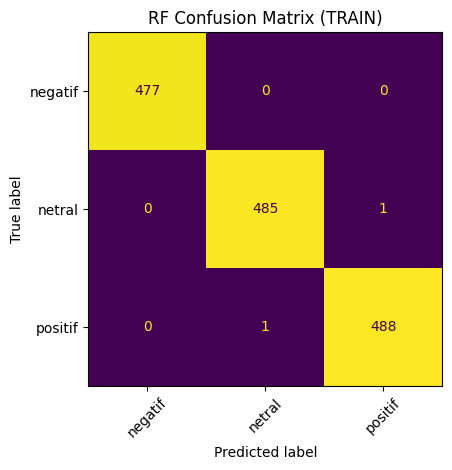

<Figure size 600x600 with 0 Axes>

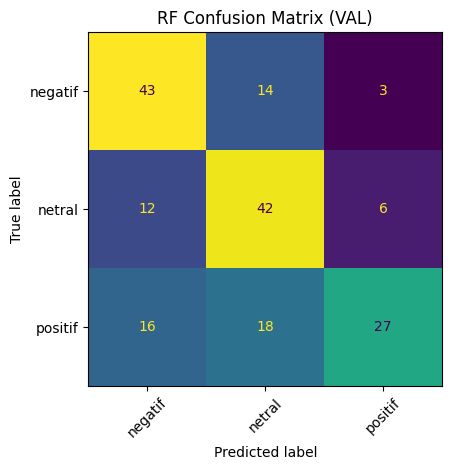

<Figure size 600x600 with 0 Axes>

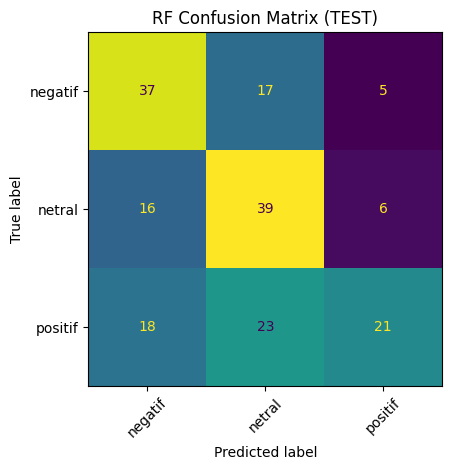

In [ ]:
print("=== TF-IDF + RandomForest (TRAIN) ===")
train_pred_rf = rf.predict(Xtr_tfidf)
print("Accuracy:", accuracy_score(y_train, train_pred_rf))
print("Macro F1 :", f1_score(y_train, train_pred_rf, average="macro"))
print(classification_report(y_train, train_pred_rf, digits=4))

print("\n=== TF-IDF + RandomForest (VAL) ===")
print("Accuracy:", accuracy_score(y_val, rf_val_pred))
print("Macro F1 :", f1_score(y_val, rf_val_pred, average="macro"))
print(classification_report(y_val, rf_val_pred, digits=4))

print("\n=== TF-IDF + RandomForest (TEST) ===")
test_pred_rf = rf.predict(Xte_tfidf)
print("Accuracy:", accuracy_score(y_test, test_pred_rf))
print("Macro F1 :", f1_score(y_test, test_pred_rf, average="macro"))
print(classification_report(y_test, test_pred_rf, digits=4))

# Confusion Matrix (TRAIN)
labels_sorted = sorted(pd.Series(y_train).unique())
cm_train = confusion_matrix(y_train, train_pred_rf, labels=labels_sorted)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels_sorted)
plt.figure(figsize=(6, 6))
disp_train.plot(xticks_rotation=45, colorbar=False)
plt.title("RF Confusion Matrix (TRAIN)")
plt.tight_layout()
plt.show()

# Confusion Matrix (VAL)
labels_sorted = sorted(pd.Series(y_val).unique())
cm_val = confusion_matrix(y_val, rf_val_pred, labels=labels_sorted)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels_sorted)
plt.figure(figsize=(6, 6))
disp_val.plot(xticks_rotation=45, colorbar=False)
plt.title("RF Confusion Matrix (VAL)")
plt.tight_layout()
plt.show()

# Confusion Matrix (TEST)
labels_sorted = sorted(pd.Series(y_test).unique())
cm_test = confusion_matrix(y_test, test_pred_rf, labels=labels_sorted)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels_sorted)
plt.figure(figsize=(6, 6))
disp_test.plot(xticks_rotation=45, colorbar=False)
plt.title("RF Confusion Matrix (TEST)")
plt.tight_layout()
plt.show()

Hasil baseline **TF-IDF + Random Forest** menunjukkan pola yang sangat jelas: performa pada data train hampir sempurna (**Accuracy 0.9986, Macro F1 0.9986**), tetapi turun cukup besar pada validation (**Macro F1 0.6134**) dan kembali turun pada test (**Macro F1 0.5244**). Gap yang sangat lebar antara train dan validation/test ini mengindikasikan bahwa model cenderung **overfit**, yaitu sangat baik dalam menghafal pola pada data latih tetapi kurang mampu melakukan generalisasi ke data yang belum pernah dilihat.

Pada validation dan test, model masih relatif lebih baik dalam mengenali kelas **negatif** dan **netral**, terutama dari sisi recall, tetapi performa pada kelas **positif** paling lemah. Di validation, recall kelas positif hanya **0.4426**, dan pada test turun lagi menjadi **0.3387**. Artinya, cukup banyak tweet positif yang gagal dikenali dengan benar dan cenderung tertukar ke kelas lain. Karena distribusi label pada dataset relatif seimbang, nilai accuracy dan macro F1 yang sama-sama menurun menunjukkan bahwa penurunan performa ini memang terjadi secara umum, bukan hanya karena bias pada satu kelas tertentu.

Kesimpulannya, ini menunjukkan bahwa kombinasi **TF-IDF + Random Forest** sudah mampu menangkap sebagian pola sentimen, tetapi belum cukup stabil sebagai model akhir. Perlu dilakukan Hypertuning Parameter supaya bisa menyelesaikan masalah overfitting, dan recall positif yang rendah

### Hypertuning Parameter

#### Pipeline hypertune (TF-IDF -> RF)

In [ ]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True)),
    ("rf", RandomForestClassifier(random_state=42, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Pada tahap tuning, digunakan **Pipeline** yang menggabungkan `TfidfVectorizer` dan `RandomForestClassifier` dalam satu pipeline supaya proses ekstraksi fitur TF-IDF dan pelatihan model dilakukan secara terintegrasi, sehingga parameter keduanya dapat di-tuning bersama. Dengan cara ini, setiap kombinasi hyperparameter akan dievaluasi menggunakan representasi TF-IDF yang dibentuk ulang secara konsisten di dalam proses training.

Selain itu, digunakan **StratifiedKFold** dengan 5 fold untuk cross-validation. Metode ini membagi data train ke dalam 5 bagian dengan proporsi kelas yang tetap seimbang pada setiap fold. Pendekatan ini membuat evaluasi tuning lebih stabil dan lebih representatif, karena model diuji beberapa kali pada pembagian data yang berbeda, bukan hanya pada satu split saja.

#### Search space

In [ ]:
param_dist = {
    # TF-IDF: bantu kurangi noise & improve separation
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [2, 3, 5],
    "tfidf__max_df": [0.85, 0.90, 0.95],
    "tfidf__max_features": [20000, 50000, None],

    # RF: atur kapasitas & generalisasi
    "rf__n_estimators": [300, 600, 1000],
    "rf__max_depth": [None, 20, 40, 60],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 5],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
    "rf__class_weight": ["balanced", "balanced_subsample"]
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
    refit=True
)

Pada proses tuning, dilakukan pencarian acak (**RandomizedSearchCV**) terhadap parameter pada dua komponen sekaligus, yaitu **TF-IDF** dan **Random Forest**. Pada TF-IDF, parameter yang diuji meliputi `ngram_range` untuk membandingkan unigram vs unigram+bigram, `min_df` untuk membuang token yang terlalu jarang, `max_df` untuk menghapus token yang terlalu umum, serta `max_features` untuk mengontrol ukuran vocabulary. Parameter-parameter ini dituning karena sangat berpengaruh terhadap kualitas representasi fitur teks dan tingkat noise pada data.

Pada Random Forest, tuning dilakukan pada `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, dan `class_weight`. Tujuannya adalah untuk mengatur kapasitas model, mencegah overfitting, serta mencari konfigurasi yang lebih mampu melakukan generalisasi pada data baru. Misalnya, `max_depth` dan `min_samples_leaf` membantu membatasi kompleksitas pohon, sedangkan `class_weight` diuji untuk melihat apakah pembobotan kelas dapat membantu performa antar label, dan `n_estimators` digunakan untuk membatasi jumlah pohon supaya biaya komputasi terbaik diketahui


Jumlah iterasi ditetapkan sebanyak **30 percobaan (`n_iter=30`)**, artinya dari seluruh kombinasi parameter yang mungkin, sistem akan mengambil 30 kombinasi secara acak untuk dievaluasi. Pendekatan ini dipilih agar proses tuning tetap efisien secara waktu dan komputasi, tetapi masih cukup luas untuk mengeksplorasi ruang hyperparameter yang relevan. Evaluasi dilakukan menggunakan **macro F1** agar performa tiap kelas diperhatikan secara seimbang.

#### Fit tuning (train only) + best params

In [ ]:
search.fit(X_train, y_train_rf)

print("\nBest CV Macro F1:", search.best_score_)
print("Best Params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV Macro F1: 0.6059404573521182
Best Params:
  tfidf__ngram_range: (1, 1)
  tfidf__min_df: 3
  tfidf__max_features: 20000
  tfidf__max_df: 0.85
  rf__n_estimators: 300
  rf__min_samples_split: 5
  rf__min_samples_leaf: 1
  rf__max_features: log2
  rf__max_depth: 60
  rf__class_weight: balanced


Hasil tuning menunjukkan bahwa kombinasi terbaik cenderung memilih konfigurasi yang **lebih sederhana dan lebih terkontrol**, bukan yang paling kompleks. Pada sisi TF-IDF, terpilihnya `ngram_range=(1,1)` menunjukkan bahwa **unigram saja sudah cukup informatif**, sedangkan penambahan bigram kemungkinan justru menambah sparsity dan noise. Nilai `min_df=3` dan `max_df=0.85` juga menunjukkan bahwa model bekerja lebih baik ketika token yang terlalu jarang dan terlalu umum disaring lebih ketat, sehingga fitur yang dipakai menjadi lebih relevan. Sementara itu, `max_features=20000` dipilih karena memberi ruang fitur yang cukup besar tanpa membuat dimensi terlalu berlebihan.

Pada sisi Random Forest, `n_estimators=300` kemungkinan sudah cukup untuk menghasilkan prediksi yang stabil, sehingga penambahan jumlah pohon lebih banyak tidak lagi memberi peningkatan berarti. Nilai `max_depth=60` menunjukkan bahwa model masih membutuhkan pohon yang cukup dalam untuk menangkap pola, tetapi tetap dibatasi agar tidak terlalu bebas seperti `None`. Parameter `min_samples_split=5` membantu menahan pohon agar tidak terlalu mudah membelah node kecil, sehingga generalisasi bisa lebih baik. Terpilihnya `max_features=log2` juga menunjukkan bahwa membatasi jumlah fitur yang dilihat pada tiap split membantu meningkatkan keragaman antar pohon, yang penting pada data TF-IDF yang sparse. Terakhir, `class_weight="balanced"` menunjukkan bahwa pembobotan kelas tetap sedikit membantu model menjaga performa antar label secara lebih seimbang.

#### Evaluate best model on Test + Val


In [ ]:
best_model = search.best_estimator_

train_pred = best_model.predict(X_train)
val_pred   = best_model.predict(X_val)
test_pred  = best_model.predict(X_test)

print("\n=== Tuned TF-IDF + RandomForest (TRAIN) ===")
print("Accuracy:", accuracy_score(y_train, train_pred))
print("Macro F1 :", f1_score(y_train, train_pred, average="macro"))
print(classification_report(y_train, train_pred, digits=4))

print("\n=== Tuned TF-IDF + RandomForest (VAL) ===")
print("Accuracy:", accuracy_score(y_val, val_pred))
print("Macro F1 :", f1_score(y_val, val_pred, average="macro"))
print(classification_report(y_val, val_pred, digits=4))

print("\n=== Tuned TF-IDF + RandomForest (TEST) ===")
print("Accuracy:", accuracy_score(y_test, test_pred))
print("Macro F1 :", f1_score(y_test, test_pred, average="macro"))
print(classification_report(y_test, test_pred, digits=4))


=== Tuned TF-IDF + RandomForest (TRAIN) ===
Accuracy: 0.9820936639118457
Macro F1 : 0.9821018892420191
              precision    recall  f1-score   support

     negatif     0.9773    0.9937    0.9854       477
      netral     0.9793    0.9753    0.9773       486
     positif     0.9896    0.9775    0.9835       489

    accuracy                         0.9821      1452
   macro avg     0.9821    0.9822    0.9821      1452
weighted avg     0.9821    0.9821    0.9821      1452


=== Tuned TF-IDF + RandomForest (VAL) ===
Accuracy: 0.6408839779005525
Macro F1 : 0.6352099234061421
              precision    recall  f1-score   support

     negatif     0.6301    0.7667    0.6917        60
      netral     0.6212    0.6833    0.6508        60
     positif     0.6905    0.4754    0.5631        61

    accuracy                         0.6409       181
   macro avg     0.6473    0.6418    0.6352       181
weighted avg     0.6475    0.6409    0.6348       181


=== Tuned TF-IDF + RandomForest

Dibandingkan baseline, model hasil tuning menunjukkan **trade-off yang cukup jelas**. Pada data train, performa turun dari hampir sempurna (**Macro F1 0.9986 -> 0.9821**), yang justru menandakan bahwa model menjadi **tidak terlalu menghafal data latih**. Pada validation, performa sedikit membaik (**Macro F1 0.6134 -> 0.6352**), sehingga tuning dapat dikatakan berhasil membuat model lebih terkontrol dan sedikit lebih baik pada split validasi. Perbaikan ini kemungkinan datang dari kombinasi filtering TF-IDF yang lebih ketat dan pembatasan kompleksitas pohon, sehingga noise berkurang dan model tidak seagresif baseline dalam membentuk pola.

Namun, pada test justru terjadi penurunan (**Macro F1 0.5244 -> 0.4978**), sehingga model tuned **tidak bisa dibilang lebih baik secara keseluruhan**. Artinya, tuning memang berhasil mengurangi overfitting terhadap train dan memberi peningkatan di validation, tetapi trade-off-nya adalah performa generalisasi akhir belum stabil, terutama karena recall kelas positif tetap rendah dan bahkan menurun pada test. Jadi, model tuned ini lebih baik jika dilihat dari **kontrol kompleksitas dan hasil validation**, tetapi belum lebih baik sebagai **model final**, karena baseline justru masih sedikit unggul pada test.

#### Confusion Matrix Test + Val

<Figure size 600x600 with 0 Axes>

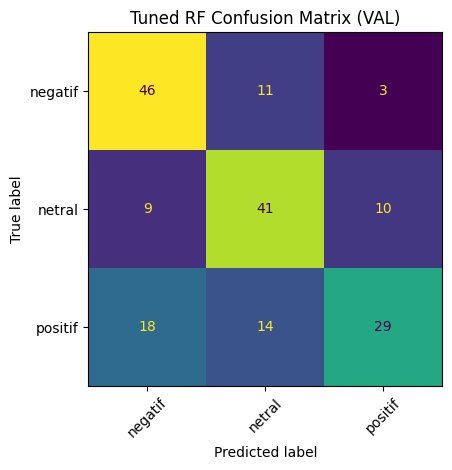

<Figure size 600x600 with 0 Axes>

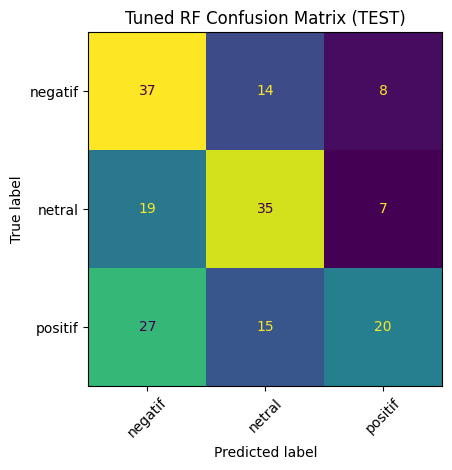

In [ ]:
# Confusion Matrix (VAL)
cm_val = confusion_matrix(y_val_rf, val_pred, labels=sorted(pd.Series(y_val_rf).unique()))
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels_sorted)

plt.figure(figsize=(6, 6))
disp_val.plot(xticks_rotation=45, colorbar=False)
plt.title("Tuned RF Confusion Matrix (VAL)")
plt.tight_layout()
plt.show()

# Confusion Matrix (TEST)
cm_test = confusion_matrix(y_test_rf, test_pred, labels=sorted(pd.Series(y_test_rf).unique()))
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels_sorted)

plt.figure(figsize=(6, 6))
disp_test.plot(xticks_rotation=45, colorbar=False)
plt.title("Tuned RF Confusion Matrix (TEST)")
plt.tight_layout()
plt.show()

Hasilnya konsisten dengan temuan kita sebelumnya, kemungkinan ini terjadi karena model hasil tuning masih belum cukup stabil untuk generalisasi, sehingga meskipun membaik di validation, performanya turun di test. Selain itu, ukuran validation dan test yang relatif kecil dapat membuat hasil cukup sensitif terhadap perbedaan sampel. Faktor lain adalah karakteristik **TF-IDF yang sparse dan high-dimensional**, yang memang kurang ideal untuk Random Forest, serta kelas positif yang masih paling sulit dibedakan dari kelas lain.

Untuk **future work**, model ini dapat dibandingkan dengan metode yang biasanya lebih cocok untuk TF-IDF, seperti **Logistic Regression** dan **Linear SVM**. Selain itu, bisa dicoba model sequence-based seperti **LSTM**(yang akan dilakukan dibawah), evaluasi yang lebih robust dengan beberapa split/cross-validation, serta analisis error khusus pada kelas positif untuk memahami pola salah prediksi.

### LSTM (Baseline)

Selain karena alasan permintaan project:)), penggunaan **LSTM** dipertimbangkan karena hasil **Random Forest + TF-IDF** menunjukkan keterbatasan dalam generalisasi, terutama dengan gap yang cukup besar antara performa train dan validation/test serta recall kelas positif yang masih rendah. Hal ini menunjukkan bahwa representasi **bag-of-words** dari TF-IDF mungkin belum cukup untuk menangkap konteks dan urutan kata secara lebih mendalam.

Berbeda dengan Random Forest, **LSTM** merupakan model sequence-based yang memproses teks sebagai urutan token, sehingga lebih mampu menangkap dependensi kata, konteks lokal, dan pola ekspresi sentimen yang tidak hanya bergantung pada kemunculan kata secara terpisah. Dengan demikian, LSTM dipilih sebagai pendekatan lanjutan untuk melihat apakah pemodelan berbasis urutan dapat memberikan generalisasi yang lebih baik dibanding baseline berbasis fitur sparse.

#### Label Preparation and Reproducibility for LSTM

In [ ]:
# Reproducibility
tf.keras.utils.set_random_seed(42)
np.random.seed(42)

# Label -> id
labels_sorted = sorted(y_train.unique())
label2id = {lbl: i for i, lbl in enumerate(labels_sorted)}
id2label = {i: lbl for lbl, i in label2id.items()}

y_train_ids = y_train.map(label2id).astype("int32").to_numpy()
y_val_ids   = y_val.map(label2id).astype("int32").to_numpy()
y_test_ids  = y_test.map(label2id).astype("int32").to_numpy()

num_classes = len(labels_sorted)

print("Labels:", labels_sorted)
print("num_classes:", num_classes)

Labels: ['negatif', 'netral', 'positif']
num_classes: 3


Berbeda dengan **Random Forest** pada scikit-learn yang masih dapat menerima label kelas dalam bentuk string, model **LSTM** pada TensorFlow/Keras membutuhkan label dalam bentuk numerik. Oleh karena itu, setiap kelas terlebih dahulu diubah dari label teks menjadi **integer id** melalui proses label encoding, misalnya dari `negatif`, `netral`, dan `positif` menjadi 0, 1, dan 2. Langkah ini diperlukan agar label dapat diproses oleh fungsi loss seperti `sparse_categorical_crossentropy`.

Selain itu, seed juga ditetapkan untuk TensorFlow dan mumpy agar hasil training lebih konsisten dan eksperimen dapat direproduksi.

#### LSTM Model Definition and Utilities

In [ ]:
num_words = 20000
tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Tentukan max_len dari train only (no leakage)
train_lens = np.array([len(seq) for seq in X_train_seq])
max_len = int(np.percentile(train_lens, 95))   # ambil p95
max_len = max(10, min(max_len, 60))            # jaga supaya ga terlalu kecil / besar

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding="post", truncating="post")

vocab_size = min(num_words, len(tokenizer.word_index) + 1)

print("\nSequence stats:")
print("Train shape:", X_train_pad.shape)
print("Val shape  :", X_val_pad.shape)
print("Test shape :", X_test_pad.shape)
print("Vocab size :", vocab_size)
print("max_len    :", max_len)
print("P95 length :", int(np.percentile(train_lens, 95)))
print("Mean length:", float(np.mean(train_lens)))


Sequence stats:
Train shape: (1452, 29)
Val shape  : (181, 29)
Test shape : (182, 29)
Vocab size : 5828
max_len    : 29
P95 length : 29
Mean length: 15.886363636363637


Next, teks diubah menjadi **urutan token integer** menggunakan `Tokenizer`. Parameter `num_words=20000` membatasi vocabulary maksimum yang dipakai, sedangkan `oov_token="<OOV>"` digunakan untuk menampung kata yang tidak masuk vocabulary agar model tetap dapat memproses token yang tidak dikenal. `Tokenizer` di-`fit` hanya pada `X_train` untuk membentuk vocabulary dari data latih, kemudian seluruh subset diubah menjadi sequence integer melalui `texts_to_sequences()`.

Setelah itu, ditentukan panjang input tetap (`max_len`) berdasarkan **persentil ke-95 (p95)** dari panjang sequence data train agar mayoritas tweet tetap terwakili tanpa terlalu dipengaruhi outlier(terlihat dari EDDA diatas). Sequence yang lebih pendek akan di-`padding`, sedangkan yang lebih panjang akan di-`truncating` di bagian akhir (`post`). Hasilnya, seluruh data memiliki bentuk yang konsisten, yaitu **train (1452, 29)**, **validation (181, 29)**, dan **test (182, 29)**, artinya setiap tweet direpresentasikan sebagai sequence sepanjang **29 token**. Nilai **vocab_size = 5828** menunjukkan jumlah kata unik yang benar-benar digunakan, sedangkan **mean length = 15.89** dan **p95 = 29** menunjukkan bahwa sebagian besar tweet relatif pendek. Dengan demikian, `max_len = 29` dapat dianggap cukup efisien karena mampu mencakup mayoritas data tanpa padding yang berlebihan.

#### LSTM Model Architecture

In [ ]:
def build_lstm_model(
    vocab_size,
    max_len,
    num_classes,
    emb_dim=128,
    lstm_units=64,
    dense_units=64,
    dropout=0.3,
    lr=1e-3
):
    model = models.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, mask_zero=True),
        layers.SpatialDropout1D(dropout),

        layers.LSTM(lstm_units, dropout=dropout, recurrent_dropout=0.0),

        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),

        layers.Dense(num_classes, activation="softmax")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

Arsitektur baseline LSTM ini dirancang cukup sederhana agar dapat berfungsi sebagai titik awal pembanding yang adil. Layer `Embedding` digunakan untuk mengubah token integer menjadi representasi vektor berdimensi **128** (`emb_dim=128`), sehingga model dapat mempelajari makna kata dalam ruang yang lebih padat dibanding representasi one-hot. Setelah itu, `SpatialDropout1D(0.3)` ditambahkan untuk mengurangi ketergantungan model pada token tertentu dan membantu menekan overfitting.

Layer utama yang digunakan adalah **LSTM dengan 64 unit** (`lstm_units=64`), yang dipilih sebagai ukuran menengah agar cukup mampu menangkap pola urutan kata tanpa membuat model terlalu kompleks. Output LSTM kemudian diteruskan ke `Dense(64, relu)` untuk mempelajari kombinasi fitur yang lebih abstrak sebelum masuk ke layer output `Dense(num_classes, softmax)` untuk klasifikasi multikelas. Nilai `dropout=0.3` digunakan sebagai regularisasi tambahan, sedangkan optimizer **Adam** dengan `learning_rate=1e-3` dipilih karena umumnya stabil dan efektif sebagai default awal dalam pelatihan model deep learning.Jadi, Kombinasi parameter ini dipilih untuk menjaga keseimbangan antara kapasitas model, stabilitas training, dan risiko overfitting pada baseline awal(yang biasanya dijadikan default), baru diujicoba nanti di tuning

#### Fungsi Plot (unruk lihat overfit tidak)

In [ ]:
def plot_history(history, title="Training History"):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist["accuracy"], label="train_acc")
    plt.plot(epochs, hist["val_accuracy"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

Fungsi `plot_history()` kami define dan gunakan untuk memvisualisasikan proses training model dari epoch ke epoch. Grafik pertama menampilkan perbandingan **train loss** dan **validation loss**, sedangkan grafik kedua menampilkan **train accuracy** dan **validation accuracy**. Visualisasi ini membantu melihat apakah model belajar dengan stabil, mengalami overfitting, atau justru underfitting.

Dengan membandingkan kurva train dan validation, kita dapat mengevaluasi dinamika pelatihan secara lebih mudah. Misalnya, jika akurasi train terus naik tetapi akurasi validation stagnan atau menurun, maka model cenderung overfit. Sebaliknya, jika keduanya sama-sama rendah, model kemungkinan masih belum cukup belajar dari data.

#### Fungsi Evaluasi

In [ ]:
def evaluate_lstm(model, X_data, y_true, split_name="VAL"):
    y_prob = model.predict(X_data, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    print(f"=== LSTM ({split_name}) ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro F1 :", f1_score(y_true, y_pred, average="macro"))
    print(classification_report(y_true, y_pred, target_names=labels_sorted, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)

    plt.figure(figsize=(6, 6))
    disp.plot(xticks_rotation=45, colorbar=False)
    plt.title(f"LSTM Confusion Matrix ({split_name})")
    plt.tight_layout()
    plt.show()

    return y_pred

Next, kita buar fungsi `evaluate_lstm()` untuk mengevaluasi performa model LSTM pada suatu subset data, seperti validation atau test. Model terlebih dahulu menghasilkan probabilitas prediksi untuk setiap kelas, lalu probabilitas tertinggi dipilih sebagai label akhir menggunakan `argmax`. Setelah itu, fungsi menampilkan metrik evaluasi utama, yaitu **accuracy**, **macro F1**, dan **classification report** agar performa tiap kelas dapat dianalisis lebih rinci.

Selain metrik numerik, fungsi ini juga menampilkan **confusion matrix** untuk melihat pola benar-salah prediksi antar kelas secara visual. Dengan begitu, evaluasi tidak hanya berfokus pada skor keseluruhan, tetapi juga membantu memahami kelas mana yang masih sering tertukar.

#### Build + Train Baseline LSTM

In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)
np.random.seed(42)

baseline_lstm = build_lstm_model(
    vocab_size=vocab_size,
    max_len=max_len,
    num_classes=num_classes,
    emb_dim=128,
    lstm_units=64,
    dense_units=64,
    dropout=0.3,
    lr=1e-3
)

baseline_lstm.summary()

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

history_baseline = baseline_lstm.fit(
    X_train_pad, y_train_ids,
    validation_data=(X_val_pad, y_val_ids),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 29, 128)        │       745,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 29, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 799,747 (3.05 MB)

 Trainable params: 799,747 (3.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.3181 - loss: 1.0976 - val_accuracy: 0.4088 - val_loss: 1.0780 - learning_rate: 0.0010
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5600 - loss: 1.0038 - val_accuracy: 0.5580 - val_loss: 1.0158 - learning_rate: 0.0010
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7544 - loss: 0.7136 - val_accuracy: 0.6133 - val_loss: 1.0192 - learning_rate: 0.0010
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8744 - loss: 0.3614 - val_accuracy: 0.6298 - val_loss: 1.1876 - learning_rate: 0.0010
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9495 - loss: 0.1734 - val_accuracy: 0.6575 - val_loss: 1.2515 - learning_rate: 5.0000e-04
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9527 - loss: 0.1527 - val_accuracy: 0.6685 - val_loss: 1.2404 - learning_rate: 5.0000e-04
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9747 - loss: 0.0944 -

Pada baseline LSTM, training dijalankan hingga **30 epoch** agar model memiliki ruang belajar yang cukup untuk menemukan pola pada data, tetapi tidak dibiarkan terus berjalan tanpa kontrol. Untuk itu, digunakan dua callback utama. **EarlyStopping** dengan `patience=5` memantau `val_loss` dan akan menghentikan training jika selama 5 epoch berturut-turut tidak ada perbaikan, lalu mengembalikan bobot terbaik. Sementara itu, **ReduceLROnPlateau** dengan `patience=2` akan menurunkan learning rate sebesar setengah (`factor=0.5`) ketika `val_loss` mulai stagnan, sehingga proses optimisasi bisa menjadi lebih halus dan stabil.

Dari proses training terlihat bahwa akurasi train meningkat cukup cepat dari sekitar **0.32** pada epoch pertama menjadi di atas **0.95** pada epoch 5-6, yang menunjukkan model mampu mempelajari pola data latih dengan cepat. Di sisi lain, **validation accuracy** juga membaik dari **0.41** menjadi sekitar **0.67**, tetapi kenaikannya jauh lebih lambat dan `val_loss` mulai berfluktuasi setelah beberapa epoch. Pola ini menunjukkan bahwa model mulai mendekati titik overfitting, sehingga kombinasi **epoch 30**, **EarlyStopping patience 5**, dan **ReduceLROnPlateau patience 2** dipilih agar model tetap punya cukup kesempatan belajar, tetapi tetap terkontrol saat performa validasi tidak lagi membaik.

#### Plot + Evaluate

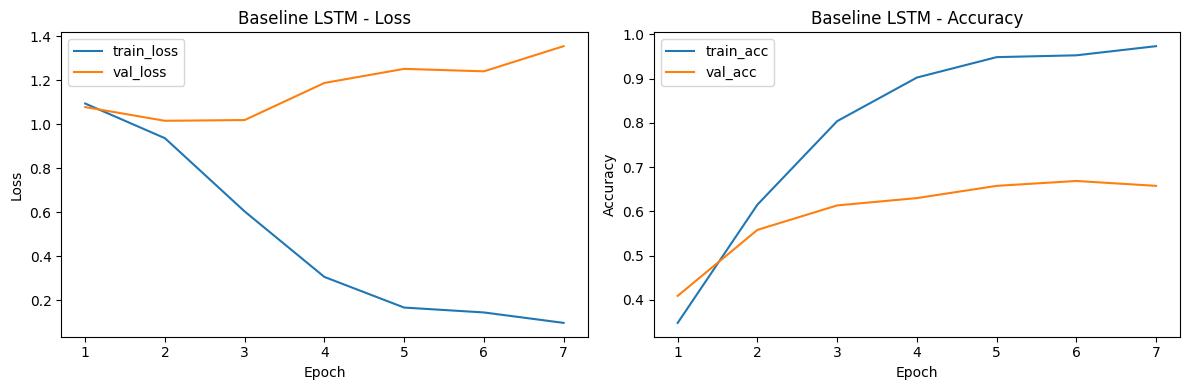

=== LSTM (TRAIN) ===
Accuracy: 0.7100550964187328
Macro F1 : 0.6912325576913689
              precision    recall  f1-score   support

     negatif     0.6241    0.9434    0.7513       477
      netral     0.7298    0.8004    0.7635       486
     positif     0.9697    0.3926    0.5590       489

    accuracy                         0.7101      1452
   macro avg     0.7746    0.7121    0.6912      1452
weighted avg     0.7759    0.7101    0.6906      1452



<Figure size 600x600 with 0 Axes>

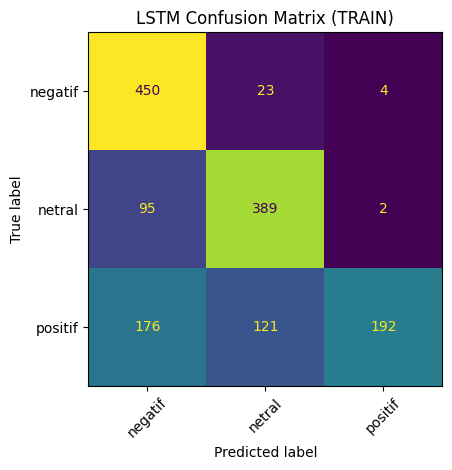

=== LSTM (VAL) ===
Accuracy: 0.5580110497237569
Macro F1 : 0.5070389653457138
              precision    recall  f1-score   support

     negatif     0.5340    0.9167    0.6748        60
      netral     0.5538    0.6000    0.5760        60
     positif     0.7692    0.1639    0.2703        61

    accuracy                         0.5580       181
   macro avg     0.6190    0.5602    0.5070       181
weighted avg     0.6198    0.5580    0.5057       181



<Figure size 600x600 with 0 Axes>

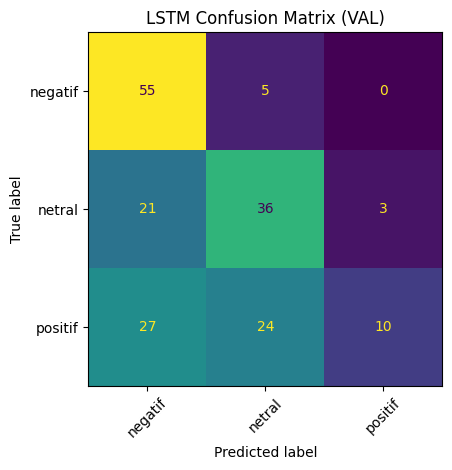

=== LSTM (TEST) ===
Accuracy: 0.46703296703296704
Macro F1 : 0.4140181433735761
              precision    recall  f1-score   support

     negatif     0.4180    0.8644    0.5635        59
      netral     0.5957    0.4590    0.5185        61
     positif     0.4615    0.0968    0.1600        62

    accuracy                         0.4670       182
   macro avg     0.4918    0.4734    0.4140       182
weighted avg     0.4924    0.4670    0.4110       182



<Figure size 600x600 with 0 Axes>

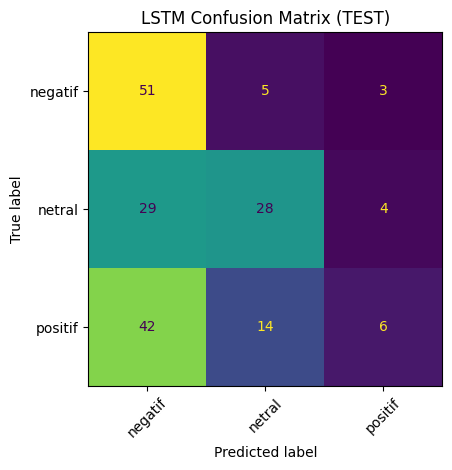

In [ ]:
plot_history(history_baseline, title="Baseline LSTM")

baseline_train_pred = evaluate_lstm(
    baseline_lstm,
    X_train_pad,
    y_train_ids,
    split_name="TRAIN"
)

baseline_val_pred = evaluate_lstm(
    baseline_lstm,
    X_val_pad,
    y_val_ids,
    split_name="VAL"
)

baseline_test_pred = evaluate_lstm(
    baseline_lstm,
    X_test_pad,
    y_test_ids,
    split_name="TEST"
)

Hasil baseline **LSTM** juga menunjukkan pola yang cukup jelas: performa pada data **train** lebih tinggi (**Accuracy 0.7101, Macro F1 0.6912**), lalu turun pada **validation** (**Macro F1 0.5070**) dan kembali turun pada **test** (**Macro F1 0.4140**). Penurunan bertahap dari train ke validation/test ini menunjukkan bahwa model **belum mampu melakukan generalisasi dengan baik**. Dari kurva training juga terlihat bahwa setelah beberapa epoch, **train loss** terus menurun tetapi **validation loss** justru meningkat, yang mengindikasikan bahwa model mulai **overfit** terhadap data latih. Namun, karena digunakan `EarlyStopping` dengan `restore_best_weights=True`, bobot akhir model dikembalikan ke epoch validasi terbaik, sehingga performa train akhir tidak setinggi puncak kurva training.

Pada validation dan test, model masih relatif lebih baik dalam mengenali kelas **negatif** dan sebagian **netral**, terutama dari sisi recall. Sebaliknya, performa pada kelas **positif** menjadi kelemahan utama. Di validation, recall kelas positif hanya **0.1639**, dan pada test turun lagi menjadi **0.0968**. Artinya, sebagian besar tweet positif gagal dikenali dengan benar dan cenderung tertukar ke kelas lain. Karena distribusi label dataset relatif seimbang, penurunan accuracy dan macro F1 ini menunjukkan bahwa masalah model bukan sekadar bias distribusi, tetapi memang keterbatasan dalam mempelajari pola sentimen secara stabil.

Kesimpulannya, baseline **LSTM** sudah dapat menangkap sebagian pola urutan pada teks, tetapi performanya masih **lebih lemah dan kurang stabil** dibandingkan baseline Random Forest sebelumnya. Masalah utamanya terletak pada generalisasi yang rendah dan recall kelas positif yang sangat kecil. Oleh karena itu, perlu dilakukan **hyperparameter tuning** pada LSTM untuk mencari konfigurasi yang lebih sesuai, baik dari sisi kapasitas model, regularisasi, maupun strategi training, agar overfitting dapat ditekan dan performa antar kelas menjadi lebih seimbang.

### LSTM (Tuned)

#### Search Space

In [ ]:
search_space = [
    {"emb_dim": 64,  "lstm_units": 64,  "dense_units": 32, "dropout": 0.2, "lr": 1e-3, "batch_size": 32},
    {"emb_dim": 64,  "lstm_units": 128, "dense_units": 32, "dropout": 0.3, "lr": 1e-3, "batch_size": 32},
    {"emb_dim": 128, "lstm_units": 64,  "dense_units": 64, "dropout": 0.3, "lr": 1e-3, "batch_size": 32},
    {"emb_dim": 128, "lstm_units": 128, "dense_units": 64, "dropout": 0.4, "lr": 1e-3, "batch_size": 32},
    {"emb_dim": 128, "lstm_units": 64,  "dense_units": 32, "dropout": 0.2, "lr": 5e-4, "batch_size": 32},
    {"emb_dim": 128, "lstm_units": 128, "dense_units": 32, "dropout": 0.3, "lr": 5e-4, "batch_size": 32},
]

Untuk tuningnya, diuji beberapa kombinasi hyperparameter LSTM yang mencakup ukuan embedding (`emb_dim`), jumlah unit LSTM (`lstm_units`), jumlah unit dense (`dense_units`), dropout, learning rate. Kombinasi ini dipilih untuk mengeksplorasi trade-off antara kaasitas model, regularisasi, dan stabilitas training.

#### Loop tuning

In [ ]:
results = []
best_model = None
best_history = None
best_config = None
best_val_f1 = -1

for i, cfg in enumerate(search_space, start=1):
    print(f"\n===== Trial {i}/{len(search_space)} =====")
    print(cfg)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)
    np.random.seed(42)

    model = build_lstm_model(
        vocab_size=vocab_size,
        max_len=max_len,
        num_classes=num_classes,
        emb_dim=cfg["emb_dim"],
        lstm_units=cfg["lstm_units"],
        dense_units=cfg["dense_units"],
        dropout=cfg["dropout"],
        lr=cfg["lr"]
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5
        )
    ]

    history = model.fit(
        X_train_pad, y_train_ids,
        validation_data=(X_val_pad, y_val_ids),
        epochs=30,
        batch_size=cfg["batch_size"],
        callbacks=callbacks,
        verbose=0
    )

    val_prob = model.predict(X_val_pad, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)

    val_acc = accuracy_score(y_val_ids, val_pred)
    val_f1  = f1_score(y_val_ids, val_pred, average="macro")

    print(f"VAL Accuracy: {val_acc:.4f}")
    print(f"VAL Macro F1: {val_f1:.4f}")

    row = {
        **cfg,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "best_epoch": int(np.argmin(history.history["val_loss"]) + 1)
    }
    results.append(row)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model = model
        best_history = history
        best_config = cfg


===== Trial 1/6 =====
{'emb_dim': 64, 'lstm_units': 64, 'dense_units': 32, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32}
VAL Accuracy: 0.5967
VAL Macro F1: 0.5847

===== Trial 2/6 =====
{'emb_dim': 64, 'lstm_units': 128, 'dense_units': 32, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 32}
VAL Accuracy: 0.6133
VAL Macro F1: 0.6130

===== Trial 3/6 =====
{'emb_dim': 128, 'lstm_units': 64, 'dense_units': 64, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 32}
VAL Accuracy: 0.5580
VAL Macro F1: 0.5070

===== Trial 4/6 =====
{'emb_dim': 128, 'lstm_units': 128, 'dense_units': 64, 'dropout': 0.4, 'lr': 0.001, 'batch_size': 32}
VAL Accuracy: 0.5525
VAL Macro F1: 0.5129

===== Trial 5/6 =====
{'emb_dim': 128, 'lstm_units': 64, 'dense_units': 32, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 32}
VAL Accuracy: 0.5691
VAL Macro F1: 0.5468

===== Trial 6/6 =====
{'emb_dim': 128, 'lstm_units': 128, 'dense_units': 32, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 32}
VAL Accuracy: 0.6298
VAL Macro F1: 0.6197


Pencarian hyperparameter dilakukan secara manual dengan mencoba setiap konfigurasi pada data train dan mengevaluasikannya pada validation set. Setiap trial dijalankan hingga maksimum 30 epoch agar seluruh konfigurasi mendapat kesempatan belajar yang cukup dan konsisten. Untuk mencegah training berjalan terlalu lama saat performa validasi tidak lagi membaik, digunakan `EarlyStopping` dengan `patience=5` serta `ReduceLROnPlateau` dengan `patience=2` agar learning rate diturunkan ketika `val_loss` mulai stagnan.

#### Hasil Tuning

In [ ]:
results_df = pd.DataFrame(results).sort_values(
    by=["val_macro_f1", "val_accuracy"],
    ascending=False
).reset_index(drop=True)

print("\n=== TUNING RESULTS ===")
display(results_df)

print("\nBest config:")
print(best_config)
print("Best VAL Macro F1:", best_val_f1)


=== TUNING RESULTS ===


,emb_dim,lstm_units,dense_units,dropout,lr,batch_size,val_accuracy,val_macro_f1,best_epoch
0,128,128,32,0.3,0.0005,32,0.629834,0.619743,4
1,64,128,32,0.3,0.0010,32,0.613260,0.612954,4
2,64,64,32,0.2,0.0010,32,0.596685,0.584688,2
3,128,64,32,0.2,0.0005,32,0.569061,0.546766,3
4,128,128,64,0.4,0.0010,32,0.552486,0.512906,2
5,128,64,64,0.3,0.0010,32,0.558011,0.507039,2



Best config:
{'emb_dim': 128, 'lstm_units': 128, 'dense_units': 32, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 32}
Best VAL Macro F1: 0.619742730616931


Hasil tuning menunjukkan bahwa konfigurasi terbaik cenderung memilih kombinasi yang **lebih kuat dari baseline, tetapi tetap cukup terkontrol**, bukan yang paling agresif dari sisi regularisasi maupun learning rate. Pada sisi representasi, terpilihnya `emb_dim=128` menunjukkan bahwa dimensi embedding yang lebih besar membantu model mempelajari representasi kata yang lebih kaya dibanding `emb_dim=64`. Hal ini masuk akal karena embedding yang lebih besar memberi ruang lebih luas untuk menangkap hubungan semantik antar kata dalam tugas klasifikasi sentimen.

Pada sisi arsitektur LSTM, terpilihnya `lstm_units=128` menunjukkan bahwa model membutuhkan kapasitas memori yang lebih besar untuk menangkap pola urutan kata secara lebih baik. Sementara itu, `dense_units=32` justru lebih kecil daripada beberapa konfigurasi lain, yang mengindikasikan bahwa setelah informasi urutan berhasil diekstrak oleh LSTM, lapisan dense yang lebih ringkas sudah cukup untuk melakukan pemetaan ke kelas output tanpa menambah kompleksitas berlebihan. Nilai `dropout=0.3` juga menunjukkan titik tengah yang cukup seimbang: tidak terlalu kecil sehingga regularisasi kurang efektif, tetapi juga tidak terlalu besar seperti `0.4` yang kemungkinan membuat model kehilangan terlalu banyak informasi saat training.

Dari sisi optimisasi, `learning_rate=0.0005` terpilih sebagai yang terbaik, yang menunjukkan bahwa langkah pembaruan bobot yang lebih kecil membuat proses training lebih stabil dibanding `0.001`. Ini sesuai dengan hasil tuning, karena beberapa konfigurasi dengan learning rate lebih besar tampak belajar lebih cepat, tetapi tidak selalu memberi validation Macro F1 terbaik. Terakhir, `batch_size=32` tetap dipertahankan pada seluruh eksperimen karena merupakan ukuran batch yang umum dan cukup stabil untuk dataset dengan ukuran seperti ini.

#### Evaluasi + Plot model terbaik

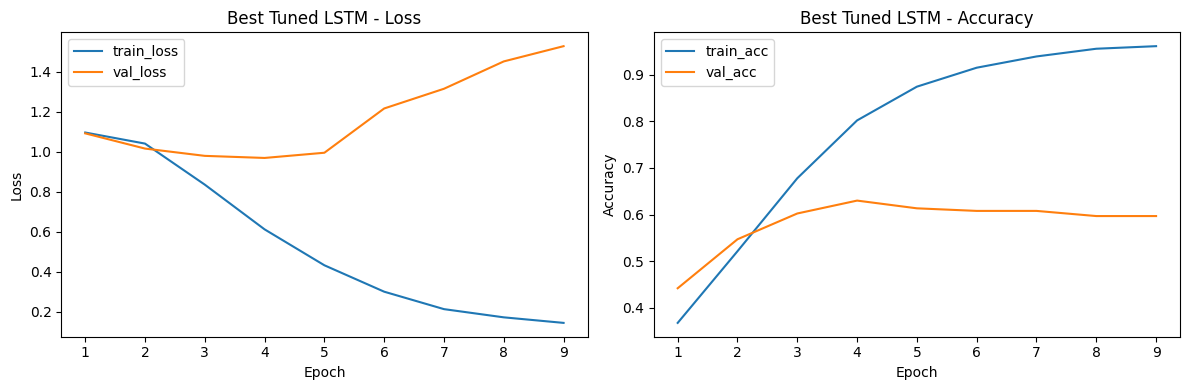

=== Best Tuned LSTM Config ===
{'emb_dim': 128, 'lstm_units': 128, 'dense_units': 32, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 32}
=== LSTM (TRAIN) ===
Accuracy: 0.900137741046832
Macro F1 : 0.8987748246657886
              precision    recall  f1-score   support

     negatif     0.8788    0.9581    0.9168       477
      netral     0.8651    0.9630    0.9114       486
     positif     0.9770    0.7812    0.8682       489

    accuracy                         0.9001      1452
   macro avg     0.9070    0.9007    0.8988      1452
weighted avg     0.9073    0.9001    0.8986      1452



<Figure size 600x600 with 0 Axes>

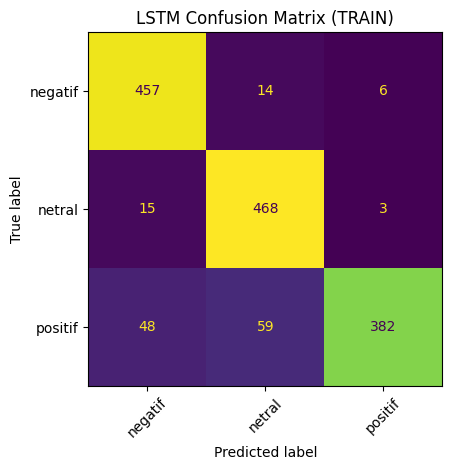

=== LSTM (VAL) ===
Accuracy: 0.6298342541436464
Macro F1 : 0.619742730616931
              precision    recall  f1-score   support

     negatif     0.6429    0.7500    0.6923        60
      netral     0.5946    0.7333    0.6567        60
     positif     0.6757    0.4098    0.5102        61

    accuracy                         0.6298       181
   macro avg     0.6377    0.6311    0.6197       181
weighted avg     0.6379    0.6298    0.6191       181



<Figure size 600x600 with 0 Axes>

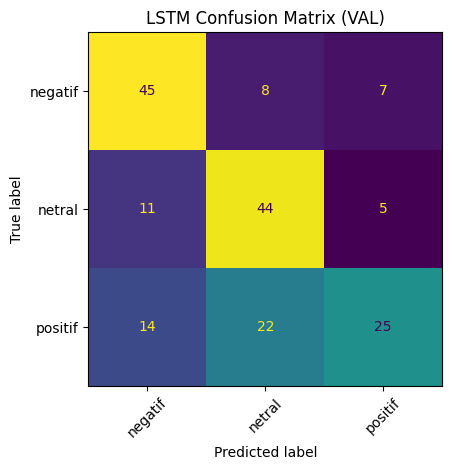

=== LSTM (TEST) ===
Accuracy: 0.5384615384615384
Macro F1 : 0.5297165414770547
              precision    recall  f1-score   support

     negatif     0.5316    0.7119    0.6087        59
      netral     0.5574    0.5574    0.5574        61
     positif     0.5238    0.3548    0.4231        62

    accuracy                         0.5385       182
   macro avg     0.5376    0.5414    0.5297       182
weighted avg     0.5376    0.5385    0.5283       182



<Figure size 600x600 with 0 Axes>

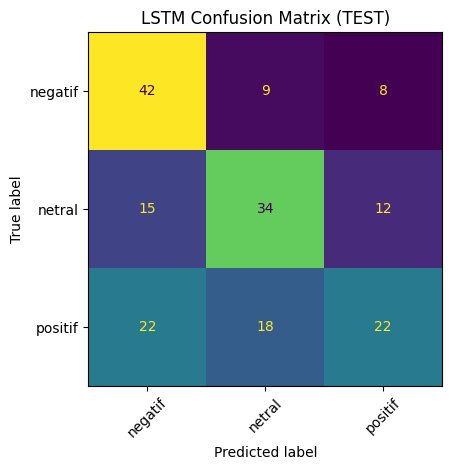

In [ ]:
plot_history(best_history, title="Best Tuned LSTM")

print("=== Best Tuned LSTM Config ===")
print(best_config)

tuned_train_pred = evaluate_lstm(
    best_model,
    X_train_pad,
    y_train_ids,
    split_name="TRAIN"
)

tuned_val_pred = evaluate_lstm(
    best_model,
    X_val_pad,
    y_val_ids,
    split_name="VAL"
)

tuned_test_pred = evaluate_lstm(
    best_model,
    X_test_pad,
    y_test_ids,
    split_name="TEST"
)

Dibandingkan baseline, model hasil tuning menunjukkan **peningkatan yang cukup jelas** pada hampir seluruh split. Pada data train, performa naik dari **Macro F1 0.6912 -> 0.8988**, yang menunjukkan bahwa model dengan konfigurasi baru memiliki kapasitas lebih baik untuk mempelajari pola pada data latih. Pada validation, performa juga meningkat dari **Macro F1 0.5070 -> 0.6197**, dan pada test naik dari **Macro F1 0.4140 -> 0.5297**. Hal ini menunjukkan bahwa tuning berhasil membuat LSTM tidak hanya lebih kuat pada data train, tetapi juga **lebih baik dalam generalisasi** dibanding baseline. Peningkatan ini kemungkinan berasal dari kombinasi embedding yang lebih besar, unit LSTM yang lebih banyak, serta learning rate yang lebih kecil sehingga proses training menjadi lebih stabil.

Meskipun demikian, kurva training masih menunjukkan adanya **indikasi overfitting**, karena `train_loss` terus menurun sementara `val_loss` meningkat setelah beberapa epoch. Artinya, model tuned tetap belajar sangat baik pada data latih, tetapi kemampuan generalisasinya belum sepenuhnya optimal. Pada validation dan test, model masih lebih baik dalam mengenali kelas **negatif** dan **netral**, sedangkan kelas **positif** tetap menjadi yang paling sulit. Namun, dibanding baseline, recall kelas positif meningkat cukup besar, yaitu dari **0.1639 -> 0.4098** pada validation dan dari **0.0968 -> 0.3548** pada test. Ini menunjukkan bahwa tuning berhasil memperbaiki kelemahan utama baseline, meskipun performa kelas positif masih paling rendah dibanding dua kelas lainnya.

Kesimpulannya, model **tuned LSTM** dapat dikatakan **lebih baik daripada baseline LSTM secara keseluruhan**, karena memberikan peningkatan yang konsisten pada validation dan test, termasuk perbaikan yang cukup berarti pada kelas positif. Jadi, berbeda dengan kasus Random Forest sebelumnya, tuning pada LSTM tidak hanya membuat model lebih terkontrol, tetapi juga benar-benar meningkatkan performa akhir. Meski begitu, karena gap train dengan validation/test masih cukup terlihat, model ini tetap memiliki ruang perbaikan lebih lanjut, terutama untuk menekan overfitting dan meningkatkan recall pada kelas positif.

#### Pembahasan Confusion Matrix & Future Works

Hasil confusion matrix menunjukkan pola yang konsisten dengan evaluasi sebelumnya. Pada data **train**, sebagian besar prediksi sudah berada pada diagonal utama, yang berarti model mampu mempelajari pola tiap kelas dengan cukup baik. Namun, pada **validation**, kelas **positif** masih paling sering tertukar, terutama ke kelas **netral**. Hal ini menunjukkan bahwa meskipun tuning berhasil meningkatkan performa LSTM dibanding baseline, model masih kesulitan membedakan ekspresi positif yang bahasanya lebih beragam atau cenderung mirip dengan netral. Selain itu, gap antara hasil train dan validation juga menandakan bahwa model masih memiliki **indikasi overfitting**, walaupun tidak separah baseline sebelumnya.

Untuk **future work**, model ini masih dapat ditingkatkan dengan beberapa cara. Pertama, melakukan tuning yang lebih luas pada kombinasi **embedding size, jumlah unit LSTM, dropout, dan learning rate**. Kedua, mencoba arsitektur yang lebih kuat seperti **BiLSTM** atau menambahkan **attention mechanism** agar model lebih peka terhadap kata-kata penting dalam tweet. Ketiga, mengeksplorasi representasi teks lain, misalnya menggunakan **Word2Vec** sebagai embedding awal, untuk melihat apakah representasi semantik yang dipelajari sebelumnya dapat membantu performa model. Keempat, membandingkan pendekatan ini dengan model transformer berbahasa Indonesia seperti **IndoBERT**, yang berpotensi menangkap konteks kalimat secara lebih baik. Kelima, melakukan evaluasi yang lebih robust dengan beberapa split atau cross-validation agar hasil tidak terlalu sensitif pada satu pembagian data. Terakhir, analisis error khusus pada kelas **positif** juga penting dilakukan untuk memahami pola salah prediksi dan memperbaiki preprocessing maupun strategi pemodelan pada tahap berikutnya.

### Perbandingan kedua Model dan Kesimpulan Akhir

| Model | Split | Accuracy | Macro F1 | Recall Negatif | Recall Netral | Recall Positif |
|---|---:|---:|---:|---:|---:|---:|
| Tuned LSTM | Train | 0.9001 | 0.8988 | 0.9581 | 0.9630 | 0.7812 |
| Tuned LSTM | Val | 0.6298 | 0.6197 | 0.7500 | 0.7333 | 0.4098 |
| Tuned LSTM | Test | 0.5385 | 0.5297 | 0.7119 | 0.5574 | 0.3548 |
| Tuned TF-IDF + Random Forest | Train | 0.9821 | 0.9821 | 0.9937 | 0.9753 | 0.9775 |
| Tuned TF-IDF + Random Forest | Val | 0.6409 | 0.6352 | 0.7667 | 0.6833 | 0.4754 |
| Tuned TF-IDF + Random Forest | Test | 0.5055 | 0.4978 | 0.6271 | 0.5738 | 0.3226 |

Secara keseluruhan, **model terbaik untuk hasil akhir adalah Tuned LSTM**, karena memberikan performa **test** yang lebih baik dibanding **Tuned TF-IDF + Random Forest**, baik dari sisi **accuracy** (**0.5385 vs 0.5055**) maupun **macro F1** (**0.5297 vs 0.4978**). Karena test set adalah acuan utama untuk menilai generalisasi pada data yang belum pernah dilihat, maka LSTM lebih layak dipilih sebagai model final.

Meski demikian, ada **trade-off** yang cukup jelas antara kedua model. **Tuned Random Forest** terlihat lebih kuat pada **train** dan sedikit lebih baik pada **validation**, yang menunjukkan bahwa model ini sangat baik dalam menangkap pola pada data latih dan split validasi. Namun, performanya turun pada test, sehingga generalisasinya kurang stabil. Sebaliknya, **Tuned LSTM** memiliki performa train yang lebih rendah, tetapi justru lebih baik bertahan pada test, sehingga dapat dikatakan lebih robust untuk data baru.

Dari sisi per kelas, kedua model sama-sama masih paling lemah pada kelas **positif**, tetapi **LSTM** memberikan hasil test yang lebih baik pada kelas ini, dengan recall positif **0.3548**, dibanding Random Forest **0.3226**. LSTM juga unggul pada recall kelas **negatif**, sedangkan Random Forest sedikit lebih baik pada recall kelas **netral**. Ini menunjukkan bahwa LSTM lebih baik dalam menangkap pola urutan dan konteks kata, sementara Random Forest lebih mengandalkan fitur kata/ngram yang muncul secara eksplisit.

Dengan demikian, **Tuned LSTM dipilih sebagai model akhir**, karena memberikan generalisasi test yang lebih baik dan performa yang lebih seimbang secara keseluruhan. Sementara itu, **Tuned TF-IDF + Random Forest** tetap berguna sebagai baseline pembanding yang kuat, terutama karena interpretasinya lebih sederhana dan performanya cukup kompetitif pada validation.

### Rekomendasi Akhir

- Menguji model klasik lain yang cocok untuk TF-IDF, seperti Logistic Regression, Linear SVM sebagai pembanding tambahan selain Random Forest.
- **Mencoba model transformer bahasa Indonesia**, seperti **IndoBERT**, untuk melihat apakah pemahaman konteks yang lebih kuat dapat meningkatkan performa, terutama pada kelas positif.
- **Menguji representasi teks lain**, misalnya **Word2Vec** atau pretrained embedding lain, lalu membandingkannya dengan embedding yang dipelajari langsung pada LSTM.
- **Mengembangkan arsitektur sequence-based yang lebih kuat**, seperti **BiLSTM** atau **LSTM + Attention**, agar model lebih peka terhadap urutan kata dan kata-kata penting dalam tweet.
- **Melakukan analisis error khusus pada kelas positif**, karena kedua model masih paling lemah pada kelas ini, sehingga pola salah prediksi dapat dipahami dan digunakan untuk memperbaiki preprocessing maupun strategi pemodelan.
- Mencoba menggunakan library stemming untuk membatasi jumlah token supaya model lebih efisien.
